In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import time
import copy
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from torchvision import datasets, transforms

# =================================================================
# RECURRENCE ENGINES (Standardized forward functions)
# =================================================================
class SimpleCFEngine(nn.Module):
    """
    Simple Continued Fraction: a_i + 1.0 / f_next
    builds from the bottom up (a_n --> _0)
    """
    def __init__(self, depth, num_ladders):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders

    def forward(self, b_i, f_prev, mask, i):
        a = 1.0
        # Pringsheim Constraint: bi > a + 1.1 for contractiveness
        b_i = F.softplus(b_i) + 2.0 # +2 ensures b >= a + 1 for stability (Pringsheim constraint)
        return b_i + mask * (a / f_prev)


class CFEngineEpsilon(nn.Module):
    """
    The Rational Engine: f = a + w*(b/f_prev)
    builds from the bottom up (a_n --> a_0)
    """
    def __init__(self, depth, num_ladders):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.full((depth, num_ladders), -1.0)) #maybe try -0.5 instead?

    def forward(self, b_i, f_prev, mask, i):
        
        a_i = self.a_scalars[i]
        return b_i + mask * (a_i / (f_prev + 1e-6))
       

class CFEngineSoftplus(nn.Module):
    """
    The Rational Engine: f = a + w*(b/f_prev)
    builds from the bottom up (a_n --> a_0)
    """
    def __init__(self, depth, num_ladders):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.full((depth, num_ladders), -1.0)) #maybe try -0.5 instead?
    
    def forward(self, b_i, f_prev, mask, i):
        
        a_i = F.softplus(self.a_scalars[i])
        #b = torch.sigmoid(self.b_scalars[i])
        # Pringsheim Constraint: ai > b + 1.1 for contractiveness
        b_i = F.softplus(b_i) + a_i + 1.0
        return b_i + mask * (a_i / f_prev)

class CFEngineSigmoid(nn.Module):
    """
    The Rational Engine: f = a + w*(b/f_prev)
    builds from the bottom up (a_n --> a_0)
    """
    def __init__(self, depth, num_ladders):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.full((depth, num_ladders), -1.0)) #maybe try -0.5 instead?
    def forward(self, b_i, f_prev, mask, i):
        
       # a is the partial numerator (the part that "floats" on top)
        # Use sigmoid to keep it between 0 and 1
        a_i = torch.sigmoid(self.a_scalars[i]) 
        
        # b is the partial denominator (the additive part)
        # Pringsheim: b >= a + 1. We'll use a smaller epsilon (0.1) for more expressivity
        # We want ai to influence the denominator
        b_i = torch.sigmoid(b_i) + a_i + 1.00
        
        # Standard Backward Recurrence: b + (a / f_prev)
        return b_i + mask * (a_i / f_prev)

class CFEngineWorpitzky(nn.Module):
    """
    The Rational Engine: f = a + w*(b/f_prev)
    builds from the bottom up (a_n --> a_0)
    """
    def __init__(self, depth, num_ladders):
        super().__init__()
        self.depth = depth
        self.num_ladders = num_ladders
        self.a_scalars = nn.Parameter(torch.full((depth, num_ladders), -1.0)) #maybe try -0.5 instead?
    
    def forward(self, b_i, f_prev, mask, i):
        # Worpitzky-style: Fix denominator at 1.0, keep numerator small
        # numerator a = 0.25 * sigmoid(ai) ensures it's always <= 0.25
        a = 0.25 * torch.sigmoid(self.a_scalars[i]) 
        
        # We use Softplus for the main path to keep the high dynamic range
        # but we treat the CF part as a small refinement
        return F.softplus(b_i) + mask * (a / f_prev)    
# =================================================================
# THE MODELS
# =================================================================

# --- GLOBAL FIX: Universal Initialization Helper ---
def initialize_weights(model): 
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)
    '''
    """
    SOTA Initialization:
    - Kaiming (He) Normal for SiLU/ReLU (Encoder/MLP layers)
    - Xavier Normal for Tanh/Softplus (Recurrence Engine logic)
    """
    for m in model.modules():
        if isinstance(m, nn.Linear):
            # Check the activation context: 
            # If the layer is part of an encoder or StandardMLP, it uses SiLU
            if "encoder" in str(m) or "net" in str(m) or "layers" in str(m):
                # He initialization is better for SiLU/ReLU
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            else:
                # Xavier is better for engines and output heads
                nn.init.xavier_normal_(m.weight)
                
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)
    '''

#Baseline model
class GeneralRecurrentModel(nn.Module):
    def __init__(self, engine, input_size=1, output_size=1, hidden_size=32, use_gating=False, affine=False):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.depth = engine.depth #how deep should each reccurence sequence be?
        self.num_ladders = engine.num_ladders #how many parallel ladders should be used?
        self.engine = engine #which reccurence formula is it using?
        self.use_gating = use_gating #is there gating?
        self.affine = affine #is there affine transformation for input (true) or a full mlp?

        if affine: #affine transformation for input
            self.a_heads = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(input_size), # Normalize features FIRST
                nn.Linear(input_size, self.num_ladders)
            ) for _ in range(self.depth)])
        else: #otherwise use full mlp
            self.encoder = nn.Sequential(nn.Linear(input_size, hidden_size), nn.LayerNorm(hidden_size), nn.SiLU()) #first half of mlp to get raw features
            self.a_heads = nn.ModuleList([nn.Linear(hidden_size, self.num_ladders) for _ in range(self.depth)]) #a_head for each a_i level, gets *num_ladders* a_i terms from raw features
        
        if self.use_gating:
            self.ladder_gates = nn.Parameter(torch.zeros(engine.num_ladders)) #gating for each ladder

        self.final_scale = nn.Linear(self.num_ladders, output_size) #scales ladder outputs down to single output

        self.layer_norm = nn.LayerNorm(self.num_ladders)

        # Initialize weights
        initialize_weights(self)

    def forward(self, x, current_max_depth=None): #current_max_depth: how many gates should be unlocked (starting at a_0)
            if self.affine:
                feat = x #if affine, only apply a_head
            else:
                feat = self.encoder(x) #get raw features
            # Seed f_n+1 = 1.0
            f_curr = torch.ones(x.shape[0], self.num_ladders).to(x.device) #start with all ones for base case/termination
            
            for i in reversed(range(self.depth)): #evaluate bottom up (a_n -> a_0)
                # Hard curriculum mask -- allow model to learn terms sequentially, gradually give more access
                mask = 1.0
                if current_max_depth is not None:
                    mask = 1.0 if i < current_max_depth else 0.0 # mask if a_i term is beyond current_max_depth
                
                # Apply engine (a_i + (mask * b_i) / f_prev for continued fractions)
                f_curr = self.engine(self.a_heads[i](feat), f_curr, mask, i)
                
                # PARITY FIX: Apply LayerNorm inside the recursion
                f_curr = self.layer_norm(f_curr)
                f_curr = torch.clamp(f_curr, 1e-6, 1e6)

            if self.use_gating:
                # Apply the gates before the final output map
                # This forces the model to decide which ladder "votes" count
                f_curr = f_curr * torch.sigmoid(self.ladder_gates)

            return self.final_scale(f_curr)      

class ContextResidualModel(nn.Module): #aka context residuals -- some weird RNN stuff
    """
    A Continued Logarithmic/Fractional Network that computes terms (a_i)
    based on the residual error of all preceding layers.
    """
    def __init__(self, engine, input_size=1, output_size=1, hidden_size=32, use_gating=False):
        super().__init__()
        self.input_size=input_size
        self.output_size=output_size
        self.engine = engine
        self.depth = engine.depth
        self.num_ladders = engine.num_ladders
        self.use_gating = use_gating #gating for ladders

        if self.use_gating:
             self.ladder_gates = nn.Parameter(torch.zeros(engine.num_ladders)) #gating for each ladder
        
        # Base Encoder for raw input X
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.SiLU()
        )
        
        # Residual Projector: Merges global features with the local error signal
        # Input size: hidden_size (X features) + output_size (Current Prediction Scalar)
        self.res_projector = nn.Linear(hidden_size + output_size, hidden_size)
        
        # Heads: One head per depth level to calculate specific a_i terms
        self.a_heads = nn.ModuleList([
            nn.Linear(hidden_size, self.num_ladders) for _ in range(self.depth)
        ])
        
        # Map the internal engine state back to the target Y-space
        self.output_map = nn.Linear(self.num_ladders, output_size)

        # Initialize weights
        initialize_weights(self)

    def forward(self, x, current_max_depth=None):
        batch_size = x.shape[0]
        device = x.device
        
        # Initial Global Features
        feat_x = self.encoder(x)
        
        # Starting state for the recurrence (f_{n+1} = 1.0)
        f_curr = torch.ones(batch_size, self.num_ladders).to(device)
        
        # We move from the bottom of the fraction (n) to the top (0)
        for i in reversed(range(self.depth)):
            if self.use_gating:
                # Apply the gates before the final output map
                # This forces the model to decide which ladder "votes" count
                f_curr = f_curr * torch.sigmoid(self.ladder_gates)
            
            # 1. Project current state to Y-space to see "where we are"
            # In an iterative sense, this is our partial convergent
            current_pred = self.output_map(f_curr)
            
            # 2. Compute "Contextual Residual"
            # We feed the model (X, current_pred) so it can focus on the 'delta'
            combined_input = torch.cat([feat_x, current_pred], dim=-1)
            refined_feat = torch.tanh(self.res_projector(combined_input))
            
            # 3. Handle Gating/Curriculum
            mask = 1.0
            if current_max_depth is not None:
                mask = 1.0 if i < current_max_depth else 0.0
            
            # 4. Generate terms a_i based on the residual-aware features
            a_i = self.a_heads[i](refined_feat)
            
            # 5. Update state through the engine
            f_curr = self.engine(a_i, f_curr, mask, i)
            
            # Stability: Prevent explosion in deep recurrences
            f_curr = torch.clamp(f_curr, -1e6, 1e6)

        # Final map to target space
        return self.output_map(f_curr)


# =================================================================
# AUTOMATED FAIRNESS ENGINE (The Parameter Matcher)
# =================================================================
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def width_to_match_params(model_factory, target_params, input_dim, output_dim, strategy="STRICT_UNDER"):
    """
    A truly agnostic solver. It just tries different widths 
    and checks the parameter count.
    """
    low, high = 4, 1024
    best_under = 4   # The "Ceiling" (max width that stays under budget)
    best_over = 1024 # The "Next Step" (min width that goes over budget)

    for _ in range(20):
        mid = (low + high) // 2
        test_model = model_factory(input_dim, output_dim, mid)
        current_count = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
        
        if current_count <= target_params:
            best_under = mid
            low = mid + 1
        else:
            best_over = mid
            high = mid - 1
            
    # Explicit logic based on your scientific requirements
    if strategy == "ALLOW_OVER": # MLP Logic: Take the next jump up
        return best_over
    
    return best_under           # CF Logic: Strictly respect the budget limit

def make_model(i, o, b, model_class, depth=4, ladders=None, engine_type=None):
    """
    Universal Factory for CF and MLP models.
    i: input_dim, o: output_dim, b: target_budget
    """
    is_mlp = (engine_type is None)
    
    # Define the 'Scientific Bias'
    # MLPs get the 'Next Step Up' while CF models stay strictly under.
    #strategy = "ALLOW_OVER" if is_mlp else "STRICT_UNDER"
    strategy = "STRICT_UNDER"

    # 1. Handle CF Models (Models that require an Engine)
    if not is_mlp:
        engine = engine_type(depth, ladders)
        def factory(in_d, out_d, width):
            return model_class(engine, in_d, out_d, width)
    else:
        def factory(in_d, out_d, width):
            return model_class(in_d, out_d, width, depth)

    width = width_to_match_params(factory, b, i, o, strategy=strategy)
    return factory(i, o, width)

def build_matching_mlp(input_dim, output_dim, target_params, target_depth, mode="standard"):
    """
    Finds the correct width for a CurriculumMLP to match the target_params.
    This ensures that regardless of depth (2 or 6), the budget remains fair.
    """
    def get_count(w):
        if mode == "standard": 
            test_model = StandardMLP(input_dim, output_dim, w, target_depth) 
        else:
            test_model = ResidualMLP(input_dim, output_dim, w, target_depth)

        return sum(p.numel() for p in test_model.parameters())
    
    # Binary search or simple increment for width
    width = 4
    while get_count(width) < target_params:
        width += 1
        
    if mode == "standard":
        return StandardMLP(input_dim, output_dim, width, target_depth)
    elif mode == "residual":
        return ResidualMLP(input_dim, output_dim, width, target_depth)
    else:
        return CurriculumMLP(input_dim, output_dim, width, target_depth)


# ==========================================
# CURRICULUM MLP (Fairness Match) -- though actually maybe does worse so not good baseline...
# ==========================================
class CurriculumMLP(nn.Module):
    """An MLP designed to be trained stage-by-stage to match CF curriculum."""
    def __init__(self, input_dim, width, depth):
        super().__init__()
        self.depth = depth
        self.layers = nn.ModuleList([nn.Linear(input_dim if i==0 else width, width) for i in range(depth)])
        self.norms = nn.ModuleList([nn.LayerNorm(width) for _ in range(depth)])
        self.head = nn.Linear(width, 1)

    def forward(self, x, current_max_depth=None):
        # If current_max_depth is 2, only use the first 2 layers
        d = self.depth if current_max_depth is None else current_max_depth
        out = x
        for i in range(d):
            out = F.silu(self.norms[i](self.layers[i](out)))
        return self.head(out)

# ==========================================
# STANDARD END-TO-END MLP (Fairness Match) --- doesn't use staged training, industry standard but maybe disadvantaged
# ==========================================
class StandardMLP(nn.Module):
    """Standard baseline: No curriculum, no gating, just deep learning."""
    def __init__(self, input_dim, output_dim, hidden_dim, depth=3):
        super().__init__()
        layers = []
        in_d = input_dim
        self.output_dim = output_dim
        for _ in range(depth):
            layers.append(nn.Linear(in_d, hidden_dim))
            layers.append(nn.LayerNorm(hidden_dim))
            layers.append(nn.SiLU())
            in_d = hidden_dim
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x, current_max_depth=None):
        # Ignore current_max_depth to ensure standard E2E training
        return self.net(x)

# ==========================================
# Residual End-to-End MLP (Fairness Match) --- to match residual CLNS
# ==========================================
class ResidualMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, depth):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.depth = depth
        # Initial projection to match hidden_dim
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.initial_norm = nn.LayerNorm(hidden_dim)
        
        # Residual Layers
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(depth)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(depth)])
        
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, current_max_depth=None):
        # Initial Projection
        x = F.silu(self.initial_norm(self.input_proj(x)))
        
        # Respecting the curriculum depth if passed
        d = self.depth if current_max_depth is None else current_max_depth
        
        for i in range(d):
            # The Residual Skip: x = x + f(x)
            # Standard "Pre-Norm" or "Post-Norm" architecture
            identity = x
            out = self.layers[i](x)
            out = self.norms[i](out)
            out = F.silu(out)
            x = identity + out
            
        return self.output_head(x)

# =================================================================
# DATA GENERATION/NORMALIZATION
# =================================================================
def get_mnist_data(use_downsampling=False, n_samples=None):
    """
    Unified MNIST loader with Downsampling Toggle.
    Ensures 'val' key exists to prevent pipeline crashes.
    """
    size = (14, 14) if use_downsampling else (28, 28)
    input_dim = size[0] * size[1]
    
    # 1. Standard Transforms
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
        transforms.Lambda(lambda x: x.view(-1))
    ])
    
    # 2. Load
    train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
    
    # 3. Pull into memory via DataLoader (applies transforms properly)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=len(train_set))
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=len(test_set))
    
    X_all_train, y_all_train = next(iter(train_loader))
    X_test, y_test = next(iter(test_loader))
    
    # 4. Optional subsampling (The 40-min Showdown Speedup)
    if n_samples and n_samples < len(X_all_train):
        indices = torch.randperm(len(X_all_train))[:n_samples]
        X_all_train, y_all_train = X_all_train[indices], y_all_train[indices]
    
    # 5. CREATE VALIDATION SPLIT (Critical for pipeline parity)
    indices = torch.randperm(len(X_all_train))
    split = int(0.85 * len(X_all_train))
    tr_idx, val_idx = indices[:split], indices[split:]
    
    # SOTA FIX: Explicitly define the stats used by the transform 
    # so the rest of the pipeline knows the data is already normalized.
    stats = {
        'x_mean': torch.tensor([0.1307]), 
        'x_std': torch.tensor([0.3081]),
        'is_pre_normalized': True 
    }
    
    return {
        'train': (X_all_train[tr_idx], y_all_train[tr_idx]),
        'val': (X_all_train[val_idx], y_all_train[val_idx]),
        'test_std': (X_test, y_test),
        'is_class': True,
        'input_dim': input_dim,
        'stats': stats # Match the regression dictionary structure
    }

def generate_dataset_pool(dataset_name, n_total=6000):
    if dataset_name == "MNIST":
        return get_mnist_data(use_downsampling=False, n_samples=20000)
    
    def compute_y(X_in, name):
        x = X_in[:, 0:1] # Use the first dimension for the primary signal
        if name == "Rational": 
            return (X_in[:, 0:1] * X_in[:, 1:2]) / (1.1 + torch.abs(X_in[:, 2:3]))
        elif name == "Singular": 
            return torch.exp(-torch.abs(x)) / (0.5 + (X_in[:, 1:2]**2))
        elif name == "Oscillatory": 
            return torch.sin(x * 2) * torch.exp(-torch.abs(X_in[:, 1:2]))
        elif name == "Sinc":
            # Removable singularity at x=0
            pi_x = torch.pi * x
            return torch.where(torch.abs(x) < 1e-6, torch.ones_like(x), torch.sin(pi_x) / pi_x)
        elif name == "Runge":
            # The classic polynomial interpolation failure test
            return 1.0 / (1.0 + 25.0 * (x ** 2))
        return None

    # 1. Get raw data
    if dataset_name == "Real World":
        from sklearn.datasets import fetch_california_housing
        data = fetch_california_housing()
        X_raw, y_raw = torch.FloatTensor(data.data), torch.FloatTensor(data.target).view(-1, 1)
    else:
        # Range [-2, 2] ensures we hit the center of the Sinc and Runge functions
        X_raw = torch.rand(n_total, 3) * 4 - 2
        y_raw = compute_y(X_raw, dataset_name)
    
    if y_raw is None:
        raise ValueError(f"Dataset name '{dataset_name}' not recognized in compute_y!")

    indices = torch.randperm(len(X_raw))
    tr_limit, val_limit = int(0.7 * len(X_raw)), int(0.85 * len(X_raw))
    tr_idx, val_idx, te_idx = indices[:tr_limit], indices[tr_limit:val_limit], indices[val_limit:]

    stats = {
        'x_mean': X_raw[tr_idx].mean(dim=0),
        'x_std': X_raw[tr_idx].std(dim=0) + 1e-6,
        'y_mean': y_raw[tr_idx].mean(),
        'y_std': y_raw[tr_idx].std() + 1e-6
    }

    def norm_x(data): return (data - stats['x_mean']) / stats['x_std']
    def norm_y(data): return (data - stats['y_mean']) / stats['y_std']

    return {
        'train': (norm_x(X_raw[tr_idx]), norm_y(y_raw[tr_idx])),
        'val': (norm_x(X_raw[val_idx]), norm_y(y_raw[val_idx])),
        'test_std': (norm_x(X_raw[te_idx]), norm_y(y_raw[te_idx])),
        'input_dim': X_raw.shape[1],
        'is_class': False,
        'stats': stats
    }

def get_mode_data(pool, mode):
    """
    Standardized data extractor. 
    Returns: X_tr, y_tr, X_val, y_val, X_te, y_te
    """
    # Base Training and Validation (now exists for all datasets)
    X_tr_raw, y_tr_raw = pool['train']
    X_val, y_val = pool['val']
    
    # 1. Handle Training Slicing (Efficiency Mode)
    if mode == "efficiency" and not pool.get('is_class', False):
        X_tr, y_tr = X_tr_raw[:400], y_tr_raw[:400]
    else:
        X_tr, y_tr = X_tr_raw, y_tr_raw

    # 2. Handle Test Set Slicing (Extrapolation vs Standard)
    if mode == "extrapolation" and 'test_ex' in pool:
        X_te, y_te = pool['test_ex']
    else:
        X_te, y_te = pool['test_std']
        
    return X_tr, y_tr, X_val, y_val, X_te, y_te

# ==========================================
# TRAINING
# ==========================================


def train_standard(model, train_loader, X_val, y_val, epochs=100, lr=0.001, patience=5, optimizer=None, is_class=False, current_depth=None):
    #now with early stopping, lr scheduler, weight decay, gradient clipping (fair since all models get it)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
       
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss() if is_class else nn.MSELoss() #label smoothing prevents the model from pushing its logits to infinity to satisfy a "hard" 1.0 target
    
    best_mse = float('inf')
    best_weights = None
    epochs_run = 0
    counter = 0

    # FIXED: MLP now uses the same validation sub-sampling as CF for fairness
    val_subset_size = min(400, len(X_val))
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            
            # Pass the depth here instead of using a lambda
            preds = model(batch_X, current_max_depth=current_depth) 
            
            target = batch_y.long().view(-1) if is_class else batch_y.view_as(preds) # .long() for CrossEntropy, .view_as() for MSE to prevent broadcasting
            loss = criterion(preds, target)
            
            loss = criterion(preds, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        epochs_run += 1
        model.eval()
        with torch.no_grad():
            v_idx = torch.randperm(len(X_val))[:val_subset_size]
            val_preds = model(X_val[v_idx])
            # FIX 2: Apply same target logic to validation
            val_target = y_val[v_idx].long().view(-1) if is_class else y_val[v_idx].view_as(val_preds)
            val_mse = criterion(val_preds, val_target).item()
        
        scheduler.step(val_mse)
        
        if val_mse < best_mse:
            if (best_mse - val_mse) > (best_mse * 0.001):
                best_weights = copy.deepcopy(model.state_dict())
            best_mse = val_mse
            counter = 0
        else:
            counter += 1
            
        if counter >= patience:
            break
            
    if best_weights:
        model.load_state_dict(best_weights)
    return best_mse, epochs_run

# ==========================================
# CURRICULUM TRAINING
# ==========================================
def train_curriculum(model, train_loader, X_val, y_val, target_depth, total_budget=100, lr=0.001, is_class=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    #optimizer = get_optimized_optimizer(model, lr=lr) 
    epochs_per_stage = max(1, total_budget // target_depth)
    total_run = 0
    
    for d in range(1, target_depth + 1):
        # NO LAMBDA NEEDED. Just pass 'd' through.
        _, ran = train_standard(model, train_loader, X_val, y_val, 
                                epochs=epochs_per_stage, optimizer=optimizer, 
                                patience=3, is_class=is_class, current_depth=d)
        total_run += ran
        
    return total_run

# ==========================================
# EVAL UTILS
# ==========================================

def get_rmse(model, x, y_true):
    """
    Calculates Root Mean Squared Error.
    Standardizes reporting for peer review.
    """
    model.eval()
    with torch.no_grad():
        predictions = model(x)
        mse = torch.nn.functional.mse_loss(predictions, y_true)
        return torch.sqrt(mse).item()

def get_score(model, x, y_true, is_classification=False):
    """
    Unified evaluation helper.
    Returns Accuracy for classification and RMSE for regression.
    """
    model.eval()
    with torch.no_grad():
        predictions = model(x)
        
        if is_classification:
            # predictions shape: [Batch, 10], y_true shape: [Batch]
            # Convert logits to class indices
            class_preds = torch.argmax(predictions, dim=1)
            correct = (class_preds == y_true).float().sum()
            return (correct / len(y_true)).item()
        else:
            # predictions shape: [Batch], y_true shape: [Batch]
            # Uses your existing get_rmse logic
            return get_rmse(model, x, y_true)

# ==========================================
# TEST SUITE
# ==========================================

def run_test_suite(config_definitions, datasets=["Real World"], modes=["standard"], target_budget=1500, trials=3):
    """
    Args:
        config_definitions: Dict of { "Model_Label": lambda input_dim, output_dim, budget: model_instance }
        datasets: List of dataset names to test
        modes: List of modes (standard, extrapolation, etc.)
    """
    results = []
    # Initialize all_models dynamically based on the passed configs
    all_models = {d: {m: {v: [] for v in config_definitions.keys()} 
                  for m in modes} for d in datasets}

    pool = {}
    for d in datasets:
        pool[d] = generate_dataset_pool(d) #generate all datasets once

    for d_name in datasets:
        # 1. Determine dimensions
        # Use the pool's stored dimensions to stay safe with downsampling
        input_dim = pool[d_name]['input_dim']
        output_dim = 10 if d_name == "MNIST" else 1
        is_class = pool[d_name].get('is_class', False)
        
        for mode in modes:
            # FIX 1: Pass the specific dataset dictionary
            X_tr, y_tr, X_val, y_val, X_te, y_te = get_mode_data(pool[d_name], mode)

            # FIX 2: Correct batch_size (Assuming global or define here)
            b_size = 1024 if is_class else 512 
            train_ds = torch.utils.data.TensorDataset(X_tr, y_tr)
            train_loader = torch.utils.data.DataLoader(train_ds, batch_size=b_size, shuffle=True)

            for v_label, model_factory in config_definitions.items():
                for t in range(trials):
                    print(f"Trial {t+1}: {d_name} | {mode} | {v_label}")
                   
                    model = model_factory(input_dim, output_dim, target_budget)
                    initialize_weights(model)
                    
                    # FIX 3: Variable name parity (train_loader)
                    if "CF" in v_label or "Curriculum" in v_label:
                        train_curriculum(model, train_loader, X_val, y_val, model.depth, is_class=is_class)
                    else:
                        train_standard(model, train_loader, X_val, y_val, is_class=is_class)
                    
                    model.eval()
                    all_models[d_name][mode][v_label].append(copy.deepcopy(model))

                    score = get_score(model, X_te, y_te, is_class)
                    
                    results.append({
                        "Dataset": d_name, 
                        "Mode": mode, 
                        "Variant": v_label,
                        "Score": score,
                        "Metric": "Accuracy" if is_class else "RMSE",
                        "Params": count_params(model)
                    })

    return pd.DataFrame(results), all_models, pool

# ==========================================
# RMSE BAR CHART PLOTTING
# ==========================================
def plot_rmse_bar_chart(df, mode="extrapolation"):
    sns.set(style="whitegrid", font_scale=1.2)
    
    # We split by 'Metric' so Accuracy and RMSE get their own charts
    metrics = df['Metric'].unique()

    for m in metrics:
        plt.figure(figsize=(12, 6))
        subset = df[(df["Mode"] == mode) & (df["Metric"] == m)]
        
        if subset.empty: continue

        g = sns.barplot(
            data=subset, 
            x="Dataset", 
            y="Score", 
            hue="Variant",
            palette="magma",
            capsize=.05,
            errorbar='sd'
        )
        
        # LOG SCALE for RMSE only
        if m == "RMSE":
            plt.yscale("log")
            plt.ylabel("RMSE (Lower is Better - Log Scale)")
        else:
            plt.ylim(0, 1.05)
            plt.ylabel("Accuracy (Higher is Better)")
            
        plt.title(f"{m} Performance: {mode.capitalize()} Mode", pad=20)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# ==========================================
# MODEL SLICE PLOTTING
# ==========================================

def plot_manifold_slices(model_dict, dataset_name, stats, pool_data=None, mode="standard", dim_to_vary=0, n_points=100):
    """
    Plots manifold slices. For 'Real World', it now plots actual test samples 
    near the manifold to serve as the Ground Truth reference.
    """
    sns.set(style="whitegrid")
    
    if dataset_name not in model_dict: return
    models_to_plot = model_dict[dataset_name][mode]

    is_class = (dataset_name == "MNIST")

    # 1. Setup Baseline from Stats (Default to zeros for MNIST if stats are missing)
    if 'x_mean' in stats:
        base_line = stats['x_mean'].clone().detach()
    else:
        # For MNIST, use the mean pixel value (usually 0.1307 if normalized)
        base_line = torch.zeros(784) 
        
    X_slice = base_line.repeat(n_points, 1)

    # 2. Define X-axis range
    if is_class:
        # MNIST normalized pixels range roughly -0.5 to 2.8
        x_min, x_max = -0.4, 2.8 
    else:
        x_min, x_max = (-2, 2) if mode == "standard" else (2, 4)
        if dataset_name == "Real World":
            x_min, x_max = -2, 4 
        
    t = torch.linspace(x_min, x_max, n_points)
    X_slice[:, dim_to_vary] = t

    plt.figure(figsize=(11, 6))

    # 3. PLOT GROUND TRUTH (Regression only)
    if not is_class:
        if dataset_name != "Real World":
            def compute_y_true(X_in, name):
                if name == "Rational": return (X_in[:, 0:1] * X_in[:, 1:2]) / (1.1 + torch.abs(X_in[:, 2:3]))
                if name == "Singular": return torch.exp(-torch.abs(X_in[:, 0:1])) / (0.5 + (X_in[:, 1:2]**2))
                if name == "Oscillatory": return torch.sin(X_in[:, 0:1] * 2) * torch.exp(-torch.abs(X_in[:, 1:2]))
            
            X_phys = X_slice * stats['x_std'] + stats['x_mean']
            y_true_raw = compute_y_true(X_phys, dataset_name)
            y_true_norm = (y_true_raw - stats['y_mean']) / stats['y_std']
            plt.plot(t.numpy(), y_true_norm.numpy(), 'k--', label="Ground Truth", linewidth=2.5, alpha=0.7)
        
        elif pool_data is not None:
            X_test, y_test = pool_data
            # Filter points "near" the slice in other dimensions
            # RELAX THE MASK: 
            # Instead of checking the MEAN diff across all features, 
            # let's just ensure the point isn't an extreme outlier in the features we aren't varying.
            diffs = torch.abs(X_test - base_line)
            # Use a median or a higher threshold (e.g., 2.0) to find "representative" points
            mask = torch.median(diffs, dim=1)[0] < 1.5 
            
            # If the mask is still too empty, just plot a random sample of 100 points
            if mask.sum() < 10:
                mask = torch.randperm(len(X_test))[:100]

            plt.scatter(X_test[mask, dim_to_vary].numpy(), y_test[mask].numpy(), 
                        color='black', s=15, alpha=0.25, label="Actual Samples (GT)", zorder=1)
    # 4. Plot Model Predictions
    colors = sns.color_palette("husl", len(models_to_plot))
    for (v_label, trials), color in zip(models_to_plot.items(), colors):
        all_trial_preds = []
        for model in trials:
            model.eval()
            with torch.no_grad():
                preds = model(X_slice)
                
                if is_class:
                    # For MNIST, we plot the confidence of the winning class
                    # Softmax makes the output 0.0 to 1.0
                    probs = F.softmax(preds, dim=-1)
                    val = torch.max(probs, dim=-1)[0]
                else:
                    # For Regression, squeeze to [n_points]
                    val = preds.squeeze()
                
                all_trial_preds.append(val.numpy())
        
        mean_pred = np.mean(all_trial_preds, axis=0)
        std_pred = np.std(all_trial_preds, axis=0)
        
        plt.plot(t.numpy(), mean_pred, label=v_label, color=color, linewidth=2, zorder=2)
        plt.fill_between(t.numpy(), mean_pred - std_pred, mean_pred + std_pred, color=color, alpha=0.15)

    # 5. Formatting
    y_label = "Confidence (Softmax Max)" if is_class else "Normalized Target Value"
    plt.ylabel(y_label)
    plt.xlabel(f"Normalized Feature {dim_to_vary}")
    plt.title(f"{dataset_name} ({mode.upper()}) - Manifold Slice", fontsize=14)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.show()


Trial 1: Sinc | standard | Standard_CF_Epsilon
Trial 2: Sinc | standard | Standard_CF_Epsilon
Trial 3: Sinc | standard | Standard_CF_Epsilon
Trial 1: Sinc | standard | Standard_CF_Softplus
Trial 2: Sinc | standard | Standard_CF_Softplus
Trial 3: Sinc | standard | Standard_CF_Softplus
Trial 1: Sinc | standard | Standard_CF_Sigmoid
Trial 2: Sinc | standard | Standard_CF_Sigmoid
Trial 3: Sinc | standard | Standard_CF_Sigmoid
Trial 1: Sinc | standard | Context_CF_Epsilon
Trial 2: Sinc | standard | Context_CF_Epsilon
Trial 3: Sinc | standard | Context_CF_Epsilon
Trial 1: Sinc | standard | Context_CF_Softplus
Trial 2: Sinc | standard | Context_CF_Softplus
Trial 3: Sinc | standard | Context_CF_Softplus
Trial 1: Sinc | standard | Context_CF_Sigmoid
Trial 2: Sinc | standard | Context_CF_Sigmoid
Trial 3: Sinc | standard | Context_CF_Sigmoid
Trial 1: Sinc | standard | MLP_Standard_Deep
Trial 2: Sinc | standard | MLP_Standard_Deep
Trial 3: Sinc | standard | MLP_Standard_Deep
Trial 1: Runge | stand

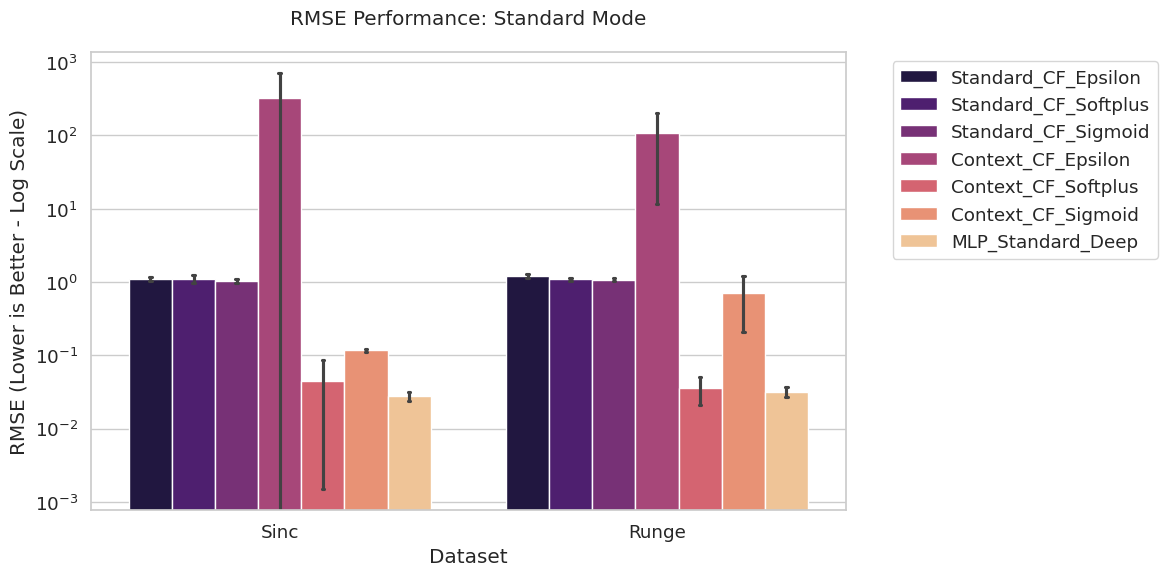

In [2]:
if __name__ == "__main__":
    depth_cf = 4

    ladder_study_configs = {
        # CF Variants
        #"Context_Resid_CF_1_L": lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, 1, CFEngine),
        #"Context_Resid_CF_2_L": lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, 2, CFEngine),
        "Context_Resid_CF_4_L": lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, 4, CFEngine),
        #"Context_Resid_CF_6_L": lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, 6, CFEngine),

        # MLP Baselines (Passing None for engine_type triggers the MLP logic)
        #"MLP_Resid_Shallow":    lambda i, o, b: make_model(i, o, b, ResidualMLP, depth=2),
        #"MLP_Resid_Deep":    lambda i, o, b: make_model(i, o, b, ResidualMLP, depth=4)
        "MLP_Standard_Shallow":    lambda i, o, b: make_model(i, o, b, StandardMLP, depth=2),
        "MLP_Standard_Deep":    lambda i, o, b: make_model(i, o, b, StandardMLP, depth=6)
       
    }

    ladder_cf = 6
    resid_configs = {
        # CF Variants
        "Context_Resid_CF": lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, ladder_cf, CFEngine),
        #"Standard_CF":  lambda i, o, b: make_model(i, o, b, GeneralRecurrentModel, depth_cf, ladder_cf, CFEngine),
        # MLP Baselines (Passing None for engine_type triggers the MLP logic)
        "MLP_Standard_Shallow":    lambda i, o, b: make_model(i, o, b, StandardMLP, depth=2),
        "MLP_Standard_Deep":    lambda i, o, b: make_model(i, o, b, StandardMLP, depth=6)
        #"MLP_Resid":    lambda i, o, b: make_model(i, o, b, ResidualMLP, depth=depth_cf),
        #"MLP_Standard":    lambda i, o, b: make_model(i, o, b, StandardMLP, depth=depth_cf)
    
    }

    pringsheim_configs = {
        "Standard_CF_Epsilon":  lambda i, o, b: make_model(i, o, b, GeneralRecurrentModel, depth_cf, ladder_cf, CFEngineEpsilon),
        "Standard_CF_Softplus":  lambda i, o, b: make_model(i, o, b, GeneralRecurrentModel, depth_cf, ladder_cf, CFEngineSoftplus),
        "Standard_CF_Sigmoid":  lambda i, o, b: make_model(i, o, b, GeneralRecurrentModel, depth_cf, ladder_cf, CFEngineSigmoid),
        "Context_CF_Epsilon":  lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, ladder_cf, CFEngineEpsilon),
        "Context_CF_Softplus":  lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, ladder_cf, CFEngineSoftplus),
        "Context_CF_Sigmoid":  lambda i, o, b: make_model(i, o, b, ContextResidualModel, depth_cf, ladder_cf, CFEngineSigmoid),
        "MLP_Standard_Deep":    lambda i, o, b: make_model(i, o, b, StandardMLP, depth=6)
       
    }

    results_df, models, data_pool = run_test_suite(
        config_definitions=pringsheim_configs,
        #datasets=["MNIST"],
        datasets = ["Sinc", "Runge"],
        modes=["standard"], #no extrapolation for mnist
        target_budget=10000 #increased to improve accuracy for MNIST
    )
    
    print("\n--- FINAL SCIENTIFIC SHOWDOWN  ---")
    # Changed 'MSE_Mean' to 'Test_MSE' to match the new results dictionary
    pivot_table = results_df.groupby(['Variant', 'Params', 'Dataset', 'Mode'])['Score'].mean().unstack()
    print(pivot_table)

    print("\n--- STABILITY CHECK (Std Dev) ---")
    std_table = results_df.groupby(['Variant',  'Params', 'Dataset', 'Mode'])['Score'].std().unstack()
    print(std_table)

    #plot_rmse_bar_chart(results_df, "extrapolation")
    plot_rmse_bar_chart(results_df, "standard")

    # Generate charts for the paper
    for d_name in ["Rational", "Singular", "Oscillatory", "Real World"]:
        if d_name in data_pool:
            current_stats = data_pool[d_name]['stats']
            
            # For Real World, we pass the test set data to enable the scatter plot
            # Mode 'test_std' for standard plots, 'test_ex' for extrapolation plots
            test_data = data_pool[d_name]['test_std'] if d_name == "Real World" else None
            ex_data = data_pool[d_name]['test_ex'] if d_name == "Real World" else None
            
            # Plot Interpolation (Standard)
            plot_manifold_slices(models, d_name, current_stats, 
                                       pool_data=test_data, mode="standard")
            
            # Plot Extrapolation
            plot_manifold_slices(models, d_name, current_stats, 
                                       pool_data=ex_data, mode="extrapolation")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a03202bf-4681-4794-bc5e-9ddbe37f4349' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>